In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams.update({
    'figure.facecolor' : '#ffffff',
    'axes.facecolor'   : '#f8f9fa',
    'axes.edgecolor'   : '#dee2e6',
    'axes.labelcolor'  : '#495057',
    'text.color'       : '#212529',
    'xtick.color'      : '#6c757d',
    'ytick.color'      : '#6c757d',
    'grid.color'       : '#e9ecef',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.7,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
sessions = pd.read_csv('../data/pre_exp_sessions.csv',
                       parse_dates=['session_start','session_end'])

print(f"Sessions loaded: {len(sessions):,}")
print(f"Columns: {sessions.columns.tolist()}")
display(sessions.head(3))

Sessions loaded: 29,122
Columns: ['session_id', 'user_pseudo_id', 'session_start', 'session_end', 'device_category', 'traffic_source', 'traffic_medium', 'item_id', 'product_category', 'price_tier', 'item_price', 'intent_level', 'dropoff_reason', 'category_viewed', 'order_id', 'order_revenue', 'page_view', 'view_item_list', 'view_item', 'add_to_cart', 'begin_checkout', 'purchase', 'avg_scroll_depth', 'reached_home', 'reached_plp', 'reached_pdp', 'reached_atc', 'reached_checkout', 'purchased', 'pdp_view_count', 'session_duration_sec', 'intent_score', 'is_returned', 'payment_method']


,session_id,user_pseudo_id,session_start,session_end,device_category,traffic_source,traffic_medium,item_id,product_category,price_tier,item_price,intent_level,dropoff_reason,category_viewed,order_id,order_revenue,page_view,view_item_list,view_item,add_to_cart,begin_checkout,purchase,avg_scroll_depth,reached_home,reached_plp,reached_pdp,reached_atc,reached_checkout,purchased,pdp_view_count,session_duration_sec,intent_score,is_returned,payment_method
0,sess_uid_00020d4f_20230712061200,uid_00020d4f,2023-07-12 06:12:13,2023-07-12 06:12:13,mobile,instagram,paid_social,LUM-BDL-01,Bundle,mid,42.99,low,price_shock,NaN,NaN,0.00,1,0,0,0,0,0,NaN,True,False,False,False,False,False,0,0.00,2,NaN,NaN
1,sess_uid_00020d4f_20230725121200,uid_00020d4f,2023-07-25 12:12:18,2023-07-25 12:12:37,mobile,google,cpc,LUM-BDL-02,Bundle,mid,39.99,high,decision_friction,Bundle,NaN,0.00,1,1,0,0,0,0,NaN,True,True,False,False,False,False,0,19.00,4,NaN,NaN
2,sess_uid_00020d4f_20230822121200,uid_00020d4f,2023-08-22 12:12:17,2023-08-22 12:13:12,mobile,google,cpc,LUM-BDL-02,Bundle,mid,39.99,high,decision_friction,Bundle,NaN,0.00,1,1,0,0,0,0,NaN,True,True,False,False,False,False,0,55.00,4,NaN,NaN


In [3]:
# ── Compute stage volumes ──────────────────────────────────────────────
home     = sessions['reached_home'].sum()
plp      = sessions['reached_plp'].sum()
pdp      = sessions['reached_pdp'].sum()
atc      = sessions['reached_atc'].sum()
checkout = sessions['reached_checkout'].sum()
purchase = sessions['purchased'].sum()
aov      = sessions.loc[sessions['purchased']==True,'order_revenue'].mean()

stages  = ['Home Page','PLP','PDP','Add to Cart','Checkout','Purchase']
volumes = [home, plp, pdp, atc, checkout, purchase]

# Step-to-step conversion rates
step_rates = [None] + [
    volumes[i]/volumes[i-1] for i in range(1,len(volumes))
]

# Drop rates (complement of step rate)
drop_rates = [None] + [
    1 - (volumes[i]/volumes[i-1]) for i in range(1,len(volumes))
]

print("=" * 68)
print(f"{'STAGE':<14} {'VOLUME':>8}  {'% OF HOME':>10}  "
      f"{'STEP CVR':>9}  {'DROP %':>8}")
print("=" * 68)
for stage,vol,rate,drop in zip(stages,volumes,step_rates,drop_rates):
    pct_home = vol/home*100
    r_str    = f"{rate:.1%}" if rate is not None else "—"
    d_str    = f"{drop:.1%}" if drop is not None else "—"
    print(f"{stage:<14} {vol:>8,}  {pct_home:>9.1f}%  {r_str:>9}  {d_str:>8}")
print("=" * 68)
print(f"\nAverage Order Value:           ${aov:.2f}")
print(f"Overall CVR (home→purchase):   {purchase/home:.2%}")
print(f"\nBiggest absolute drop-off:")
drops = [(stages[i+1], volumes[i]-volumes[i+1], 1-(volumes[i+1]/volumes[i]))
         for i in range(len(volumes)-1)]
biggest = max(drops, key=lambda x: x[1])
print(f"  Stage: {biggest[0]}  |  Users lost: {biggest[1]:,}  "
      f"|  Drop rate: {biggest[2]:.1%}")

STAGE            VOLUME   % OF HOME   STEP CVR    DROP %
Home Page        29,122      100.0%          —         —
PLP              16,614       57.0%      57.0%     43.0%
PDP               7,836       26.9%      47.2%     52.8%
Add to Cart       3,138       10.8%      40.0%     60.0%
Checkout          1,701        5.8%      54.2%     45.8%
Purchase          1,418        4.9%      83.4%     16.6%

Average Order Value:           $44.06
Overall CVR (home→purchase):   4.87%

Biggest absolute drop-off:
  Stage: PLP  |  Users lost: 12,508  |  Drop rate: 43.0%


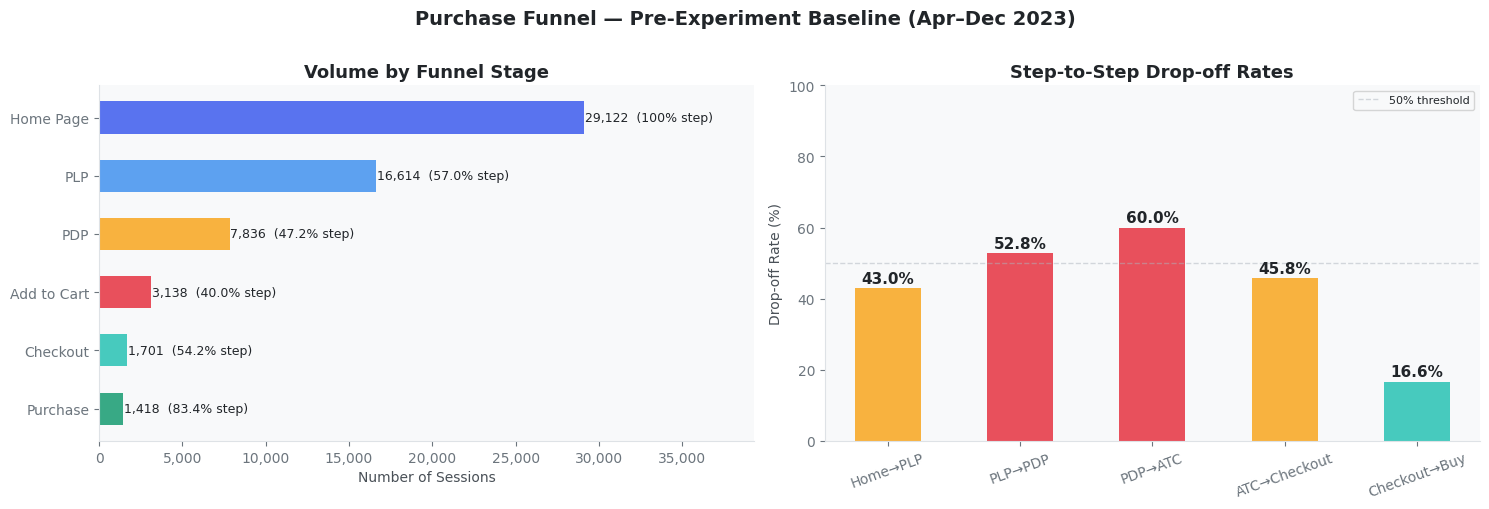

Saved: funnel_overview.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Purchase Funnel — Pre-Experiment Baseline (Apr–Dec 2023)',
             fontsize=14, fontweight='bold', y=1.01)

stage_colors = [
    '#4361ee',  # Home
    '#4895ef',  # PLP
    '#f9a825',  # PDP
    '#e63946',  # ATC ← biggest drop
    '#2ec4b6',  # Checkout
    '#1d9e75',  # Purchase
]

# ── Left: horizontal bar funnel ───────────────────────────────────────
ax = axes[0]
bars = ax.barh(stages[::-1], volumes[::-1],
               color=stage_colors[::-1], height=0.55, alpha=0.88)
ax.set_xlabel('Number of Sessions')
ax.set_title('Volume by Funnel Stage')
ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x,_: f'{int(x):,}'))

for bar, vol, rate in zip(bars, volumes[::-1], step_rates[::-1]):
    r_str = f"{rate:.1%}" if rate is not None else "100%"
    ax.text(bar.get_width()+50,
            bar.get_y()+bar.get_height()/2,
            f'{vol:,}  ({r_str} step)',
            va='center', fontsize=9, color='#212529')
ax.set_xlim(0, max(volumes)*1.35)

# ── Right: step-to-step drop rates ───────────────────────────────────
ax2    = axes[1]
labels = ['Home→PLP','PLP→PDP','PDP→ATC','ATC→Checkout','Checkout→Buy']
drops  = [d for d in drop_rates if d is not None]
bcolors= [
    '#e63946' if d > 0.50 else
    '#f9a825' if d > 0.35 else
    '#2ec4b6'
    for d in drops
]
bars2 = ax2.bar(labels, [d*100 for d in drops],
                color=bcolors, width=0.5, alpha=0.88)
ax2.set_ylabel('Drop-off Rate (%)')
ax2.set_title('Step-to-Step Drop-off Rates')
ax2.set_ylim(0, 100)
ax2.axhline(50, color='#adb5bd', linestyle='--',
            linewidth=1, alpha=0.5, label='50% threshold')
ax2.legend(fontsize=8)

for bar, d in zip(bars2, drops):
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+1.5,
             f'{d:.1%}', ha='center', fontsize=11,
             fontweight='bold', color='#212529')
ax2.tick_params(axis='x', labelrotation=20)

plt.tight_layout()
plt.savefig('../data/funnel_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: funnel_overview.png")

DROP-OFF STAGE BY TRAFFIC SOURCE

Key question: does each source drop off at the same stage
or does low-intent social traffic drop off earlier
(at Home or PLP) while high-intent direct/email reaches PDP?


Source         Share   H→PLP  PLP→PDP  PDP→ATC  Overall
----------------------------------------------------------
direct        11.9%   79.8%    65.5%    46.1%    11.1%
email         18.0%   81.9%    64.2%    45.5%    10.5%
google        19.9%   66.1%    47.0%    39.9%     5.8%
referral       7.7%   63.2%    48.2%    35.7%     4.7%
instagram     32.8%   35.2%    18.7%    11.5%     0.3%
tiktok         9.7%   33.6%    16.1%     8.5%     0.1%


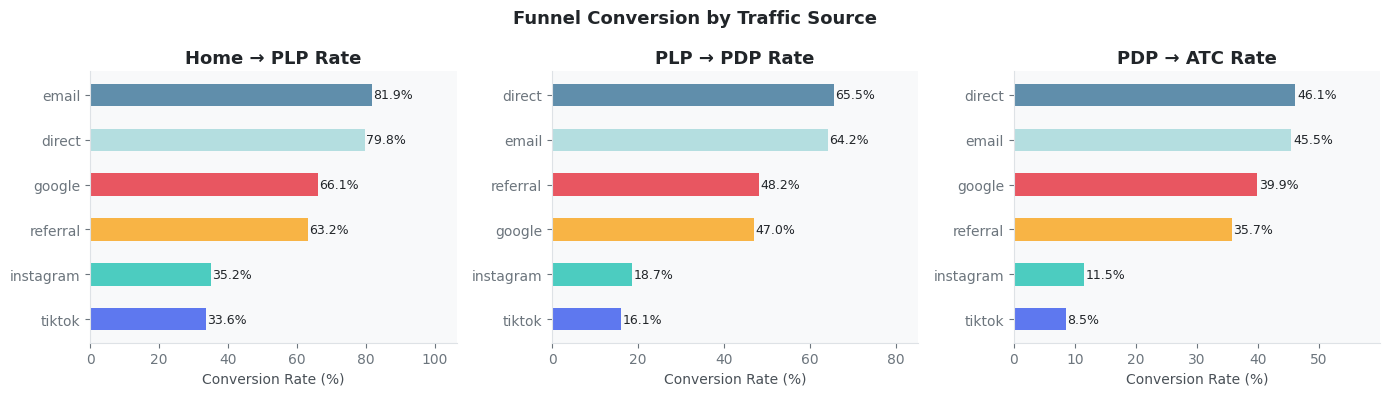


💡 Key Finding:
  Direct has highest CVR (11.1%) — high-intent channel
  Tiktok has lowest CVR (0.1%) — low-intent channel
  Social (FB+IG) loses 64.8% of users at Home Page alone


In [5]:
print("=" * 62)
print("DROP-OFF STAGE BY TRAFFIC SOURCE")
print("=" * 62)
print("""
Key question: does each source drop off at the same stage
or does low-intent social traffic drop off earlier
(at Home or PLP) while high-intent direct/email reaches PDP?
""")

source_funnel = (
    sessions.groupby('traffic_source')
    .agg(
        sessions      = ('traffic_source',   'count'),
        reached_plp   = ('reached_plp',      'sum'),
        reached_pdp   = ('reached_pdp',      'sum'),
        reached_atc   = ('reached_atc',      'sum'),
        purchased     = ('purchased',         'sum'),
    )
    .reset_index()
)

source_funnel['home_to_plp'] = source_funnel['reached_plp']  / source_funnel['sessions']
source_funnel['plp_to_pdp']  = source_funnel['reached_pdp']  / source_funnel['reached_plp']
source_funnel['pdp_to_atc']  = source_funnel['reached_atc']  / source_funnel['reached_pdp']
source_funnel['overall_cvr'] = source_funnel['purchased']     / source_funnel['sessions']
source_funnel['traffic_share'] = source_funnel['sessions']   / source_funnel['sessions'].sum()

# Sort by overall CVR
source_funnel = source_funnel.sort_values('overall_cvr', ascending=False)

print(f"\n{'Source':<12} {'Share':>7} {'H→PLP':>7} {'PLP→PDP':>8} "
      f"{'PDP→ATC':>8} {'Overall':>8}")
print("-" * 58)
for _, row in source_funnel.iterrows():
    print(f"{row['traffic_source']:<12} "
          f"{row['traffic_share']:>6.1%} "
          f"{row['home_to_plp']:>7.1%} "
          f"{row['plp_to_pdp']:>8.1%} "
          f"{row['pdp_to_atc']:>8.1%} "
          f"{row['overall_cvr']:>8.1%}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Funnel Conversion by Traffic Source',
             fontsize=13, fontweight='bold')

metrics = [
    ('home_to_plp', 'Home → PLP Rate'),
    ('plp_to_pdp',  'PLP → PDP Rate'),
    ('pdp_to_atc',  'PDP → ATC Rate'),
]
palette = ['#4361ee','#2ec4b6','#f9a825','#e63946','#a8dadc','#457b9d']

for ax, (col, title) in zip(axes, metrics):
    sf = source_funnel.sort_values(col, ascending=True)
    bars = ax.barh(sf['traffic_source'], sf[col]*100,
                   color=palette[:len(sf)], height=0.5, alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('Conversion Rate (%)')
    for bar, v in zip(bars, sf[col]):
        ax.text(bar.get_width()+0.3,
                bar.get_y()+bar.get_height()/2,
                f'{v:.1%}', va='center', fontsize=9)
    ax.set_xlim(0, sf[col].max()*130)

plt.tight_layout()
plt.savefig('../data/funnel_by_source.png', dpi=150, bbox_inches='tight')
plt.show()

# Key insight
best  = source_funnel.iloc[0]
worst = source_funnel.iloc[-1]
print(f"\n💡 Key Finding:")
print(f"  {best['traffic_source'].capitalize()} has highest CVR "
      f"({best['overall_cvr']:.1%}) — high-intent channel")
print(f"  {worst['traffic_source'].capitalize()} has lowest CVR "
      f"({worst['overall_cvr']:.1%}) — low-intent channel")
home_drop_social = 1 - source_funnel[
    source_funnel['traffic_source'].isin(['facebook','instagram'])
]['home_to_plp'].mean()
print(f"  Social (FB+IG) loses {home_drop_social:.1%} of users at Home Page alone")

PDP DROP-OFF DEEP DIVE — BY PRICE TIER

Funnel rates by price tier:


,price_tier,pdp_users,pdp_to_atc,atc_to_checkout,checkout_to_pur,avg_pdp_views,avg_scroll,avg_dur_min
1,low,4280,0.42,0.59,0.86,1.50,0.55,3.60
2,mid,2933,0.41,0.48,0.79,1.49,0.56,3.44
0,high,623,0.26,0.49,0.73,1.44,0.50,3.11


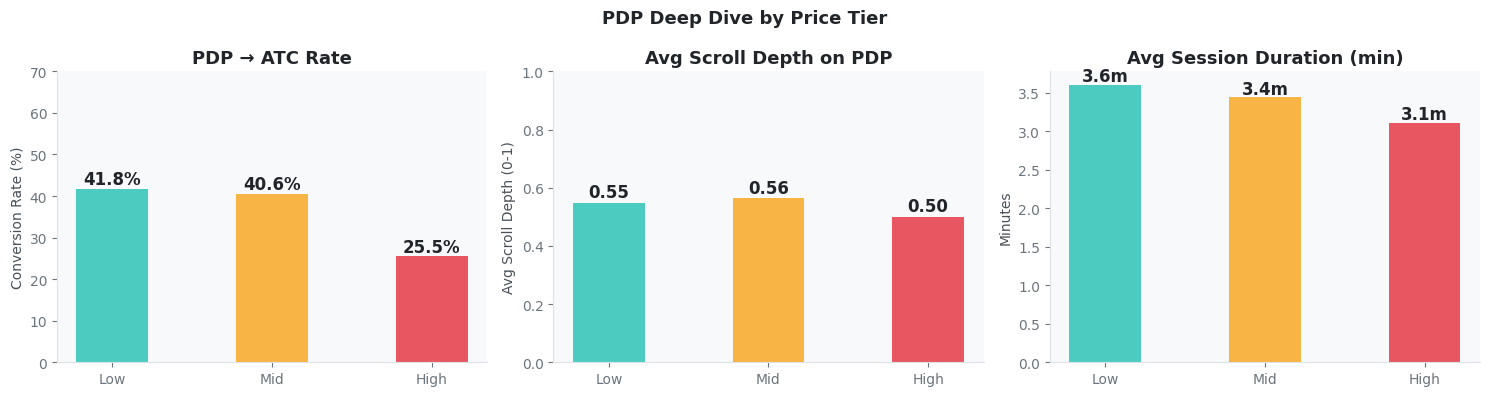

In [6]:
print("=" * 55)
print("PDP DROP-OFF DEEP DIVE — BY PRICE TIER")
print("=" * 55)

pdp_sessions = sessions[sessions['reached_pdp']==True].copy()

tier_funnel = (
    pdp_sessions.groupby('price_tier')
    .agg(
        pdp_users        = ('reached_pdp',       'sum'),
        atc_users        = ('reached_atc',       'sum'),
        checkout_users   = ('reached_checkout',  'sum'),
        purchase_users   = ('purchased',         'sum'),
        avg_pdp_views    = ('pdp_view_count',    'mean'),
        avg_scroll       = ('avg_scroll_depth',  'mean'),
        avg_dur_sec      = ('session_duration_sec','mean'),
    )
    .reset_index()
)

tier_funnel['pdp_to_atc']      = tier_funnel['atc_users']     / tier_funnel['pdp_users']
tier_funnel['atc_to_checkout'] = tier_funnel['checkout_users']/ tier_funnel['atc_users']
tier_funnel['checkout_to_pur'] = tier_funnel['purchase_users']/ tier_funnel['checkout_users']
tier_funnel['avg_dur_min']     = tier_funnel['avg_dur_sec'] / 60

tier_order = ['low','mid','high']
tier_funnel['price_tier'] = pd.Categorical(tier_funnel['price_tier'], tier_order)
tier_funnel = tier_funnel.sort_values('price_tier')

print("\nFunnel rates by price tier:")
display(tier_funnel[[
    'price_tier','pdp_users','pdp_to_atc',
    'atc_to_checkout','checkout_to_pur',
    'avg_pdp_views','avg_scroll','avg_dur_min'
]].round(3))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('PDP Deep Dive by Price Tier', fontsize=13, fontweight='bold')

tier_colors = ['#2ec4b6','#f9a825','#e63946']
tier_labels = [t.capitalize() for t in tier_funnel['price_tier']]

# PDP → ATC
ax = axes[0]
bars = ax.bar(tier_labels, tier_funnel['pdp_to_atc']*100,
              color=tier_colors, width=0.45, alpha=0.85)
ax.set_title('PDP → ATC Rate')
ax.set_ylabel('Conversion Rate (%)')
ax.set_ylim(0, 70)
for bar, v in zip(bars, tier_funnel['pdp_to_atc']):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+1,
            f'{v:.1%}', ha='center', fontsize=12, fontweight='bold')

# Avg scroll depth
ax2 = axes[1]
bars2 = ax2.bar(tier_labels, tier_funnel['avg_scroll'],
                color=tier_colors, width=0.45, alpha=0.85)
ax2.set_title('Avg Scroll Depth on PDP')
ax2.set_ylabel('Avg Scroll Depth (0-1)')
ax2.set_ylim(0, 1.0)
for bar, v in zip(bars2, tier_funnel['avg_scroll']):
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.02,
             f'{v:.2f}', ha='center', fontsize=12, fontweight='bold')

# Avg session duration
ax3 = axes[2]
bars3 = ax3.bar(tier_labels, tier_funnel['avg_dur_min'],
                color=tier_colors, width=0.45, alpha=0.85)
ax3.set_title('Avg Session Duration (min)')
ax3.set_ylabel('Minutes')
for bar, v in zip(bars3, tier_funnel['avg_dur_min']):
    ax3.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.05,
             f'{v:.1f}m', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/pdp_dropoff_tier.png', dpi=150, bbox_inches='tight')
plt.show()

DROP-OFF REASON BREAKDOWN — THE NEW INSIGHT

This analysis is unique to our enriched dataset.
Instead of just knowing WHERE users drop off,
we now know WHY — and can target each reason differently.

Drop-off reason breakdown at PDP stage:


,dropoff_reason,sessions,pct_of_pdp,atc_rate,avg_scroll,avg_dur_min,avg_pdp_views
2,converted,3202,0.41,0.86,0.74,4.30,1.50
7,price_barrier,1309,0.17,0.04,0.18,1.54,1.00
3,decision_friction,1080,0.14,0.17,0.79,6.32,2.63
1,comparison_intent,771,0.10,0.12,0.63,3.29,1.60
4,distraction,431,0.06,0.03,0.37,1.56,1.00
6,out_of_stock,363,0.05,0.03,0.32,1.55,1.00
8,price_shock,248,0.03,0.02,0.23,1.49,1.00
5,impulse_faded,233,0.03,0.05,0.11,1.55,1.00
9,wrong_audience,146,0.02,0.03,0.03,1.55,1.00
0,ad_pdp_mismatch,53,0.01,0.00,0.06,1.42,1.00


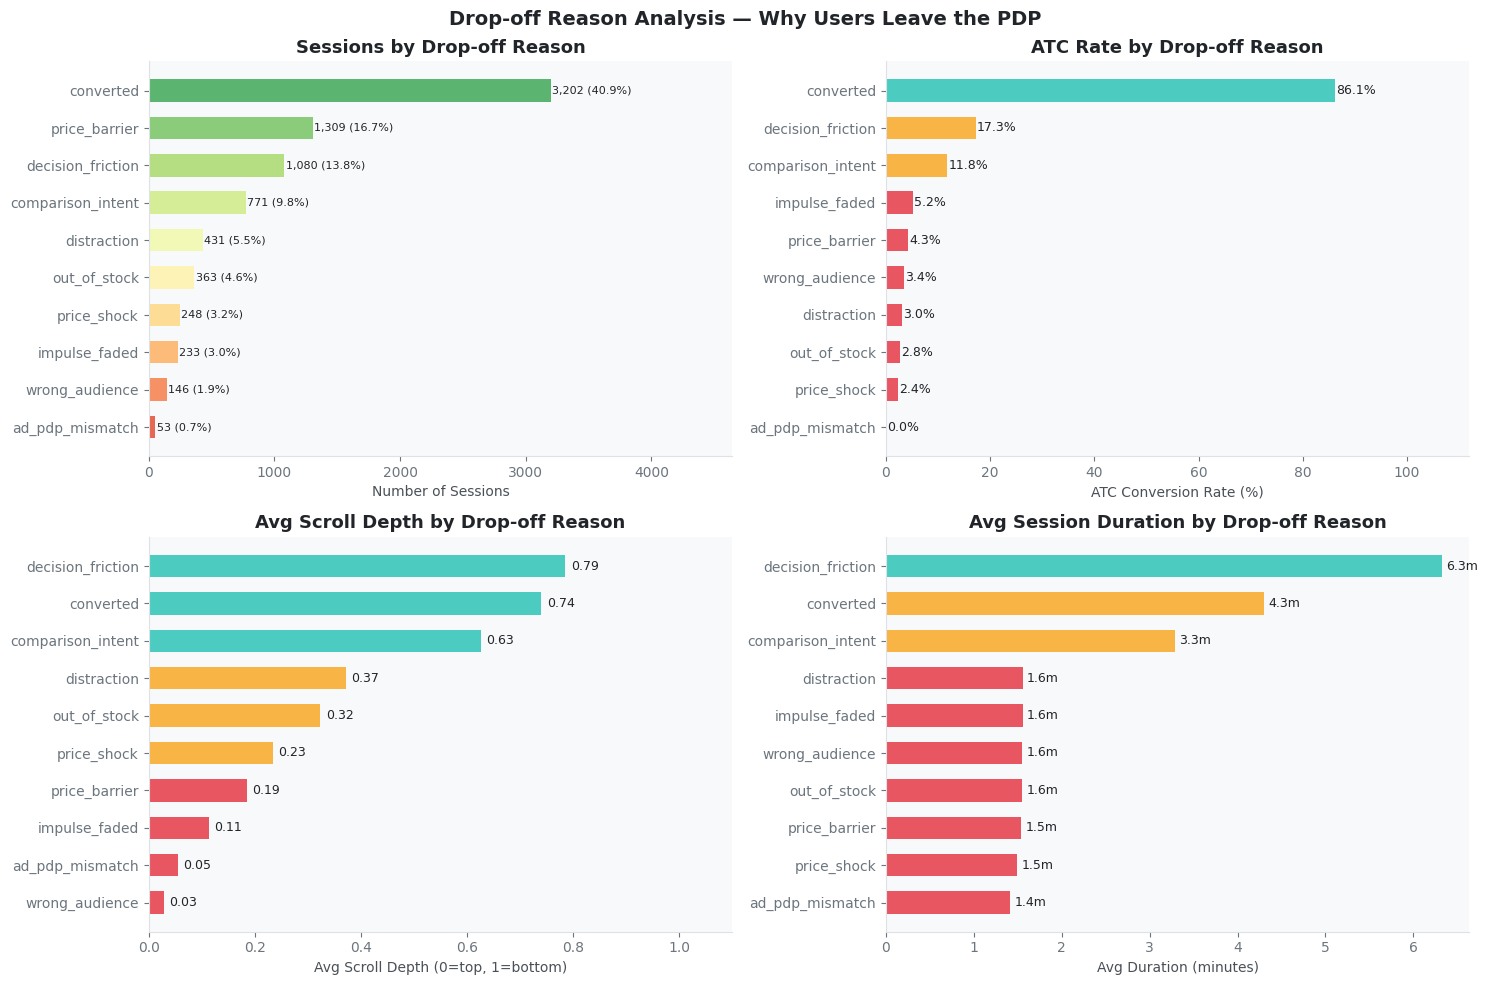

In [7]:
print("=" * 62)
print("DROP-OFF REASON BREAKDOWN — THE NEW INSIGHT")
print("=" * 62)
print("""
This analysis is unique to our enriched dataset.
Instead of just knowing WHERE users drop off,
we now know WHY — and can target each reason differently.
""")

# Overall drop-off reason distribution at PDP
reason_summary = (
    pdp_sessions.groupby('dropoff_reason')
    .agg(
        sessions      = ('dropoff_reason',   'count'),
        atc_users     = ('reached_atc',       'sum'),
        avg_scroll    = ('avg_scroll_depth',  'mean'),
        avg_dur_sec   = ('session_duration_sec','mean'),
        avg_pdp_views = ('pdp_view_count',    'mean'),
    )
    .reset_index()
)

reason_summary['atc_rate']    = reason_summary['atc_users'] / reason_summary['sessions']
reason_summary['avg_dur_min'] = reason_summary['avg_dur_sec'] / 60
reason_summary['pct_of_pdp']  = reason_summary['sessions'] / len(pdp_sessions)
reason_summary = reason_summary.sort_values('sessions', ascending=False)

print("Drop-off reason breakdown at PDP stage:")
display(reason_summary[[
    'dropoff_reason','sessions','pct_of_pdp',
    'atc_rate','avg_scroll','avg_dur_min','avg_pdp_views'
]].round(3))

# Visualization — 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Drop-off Reason Analysis — Why Users Leave the PDP',
             fontsize=14, fontweight='bold')

rs = reason_summary.sort_values('sessions', ascending=True)
reason_colors = plt.cm.RdYlGn(
    np.linspace(0.15, 0.85, len(rs)))

# Top-left: session count by reason
ax = axes[0,0]
bars = ax.barh(rs['dropoff_reason'], rs['sessions'],
               color=reason_colors, height=0.6, alpha=0.85)
ax.set_title('Sessions by Drop-off Reason')
ax.set_xlabel('Number of Sessions')
for bar, val, pct in zip(bars, rs['sessions'], rs['pct_of_pdp']):
    ax.text(bar.get_width()+10,
            bar.get_y()+bar.get_height()/2,
            f'{val:,} ({pct:.1%})',
            va='center', fontsize=8)
ax.set_xlim(0, rs['sessions'].max()*1.45)

# Top-right: ATC rate by reason
ax2 = axes[0,1]
rs2 = reason_summary.sort_values('atc_rate', ascending=True)
atc_colors = ['#e63946' if v < 0.10 else
              '#f9a825' if v < 0.30 else
              '#2ec4b6'
              for v in rs2['atc_rate']]
bars2 = ax2.barh(rs2['dropoff_reason'], rs2['atc_rate']*100,
                 color=atc_colors, height=0.6, alpha=0.85)
ax2.set_title('ATC Rate by Drop-off Reason')
ax2.set_xlabel('ATC Conversion Rate (%)')
for bar, v in zip(bars2, rs2['atc_rate']):
    ax2.text(bar.get_width()+0.2,
             bar.get_y()+bar.get_height()/2,
             f'{v:.1%}', va='center', fontsize=9)
ax2.set_xlim(0, rs2['atc_rate'].max()*130)

# Bottom-left: scroll depth by reason
ax3 = axes[1,0]
rs3 = reason_summary.sort_values('avg_scroll', ascending=True)
scroll_colors = ['#e63946' if v < 0.20 else
                 '#f9a825' if v < 0.50 else
                 '#2ec4b6'
                 for v in rs3['avg_scroll']]
bars3 = ax3.barh(rs3['dropoff_reason'], rs3['avg_scroll'],
                 color=scroll_colors, height=0.6, alpha=0.85)
ax3.set_title('Avg Scroll Depth by Drop-off Reason')
ax3.set_xlabel('Avg Scroll Depth (0=top, 1=bottom)')
ax3.set_xlim(0, 1.1)
for bar, v in zip(bars3, rs3['avg_scroll']):
    ax3.text(bar.get_width()+0.01,
             bar.get_y()+bar.get_height()/2,
             f'{v:.2f}', va='center', fontsize=9)

# Bottom-right: session duration by reason
ax4 = axes[1,1]
rs4 = reason_summary.sort_values('avg_dur_min', ascending=True)
dur_colors = ['#e63946' if v < 2 else
              '#f9a825' if v < 5 else
              '#2ec4b6'
              for v in rs4['avg_dur_min']]
bars4 = ax4.barh(rs4['dropoff_reason'], rs4['avg_dur_min'],
                 color=dur_colors, height=0.6, alpha=0.85)
ax4.set_title('Avg Session Duration by Drop-off Reason')
ax4.set_xlabel('Avg Duration (minutes)')
for bar, v in zip(bars4, rs4['avg_dur_min']):
    ax4.text(bar.get_width()+0.05,
             bar.get_y()+bar.get_height()/2,
             f'{v:.1f}m', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/dropoff_reason_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

DROP-OFF REASON × PRICE TIER

The most important cross-tab in the entire analysis.
Shows that high-price products have more decision_friction
and comparison_intent — actionable reasons we CAN fix.
Low-price products have more impulse/wrong_audience —
harder to fix with PDP content.


Drop-off reason mix by price tier (% of PDP sessions in that tier):


price_tier,low,mid,high
dropoff_reason,,,
ad_pdp_mismatch,0.00,0.00,0.09
comparison_intent,0.08,0.09,0.25
converted,0.41,0.43,0.27
decision_friction,0.14,0.14,0.11
distraction,0.06,0.06,0.03
impulse_faded,0.03,0.03,0.03
out_of_stock,0.05,0.05,0.00
price_barrier,0.17,0.17,0.14
price_shock,0.03,0.03,0.06


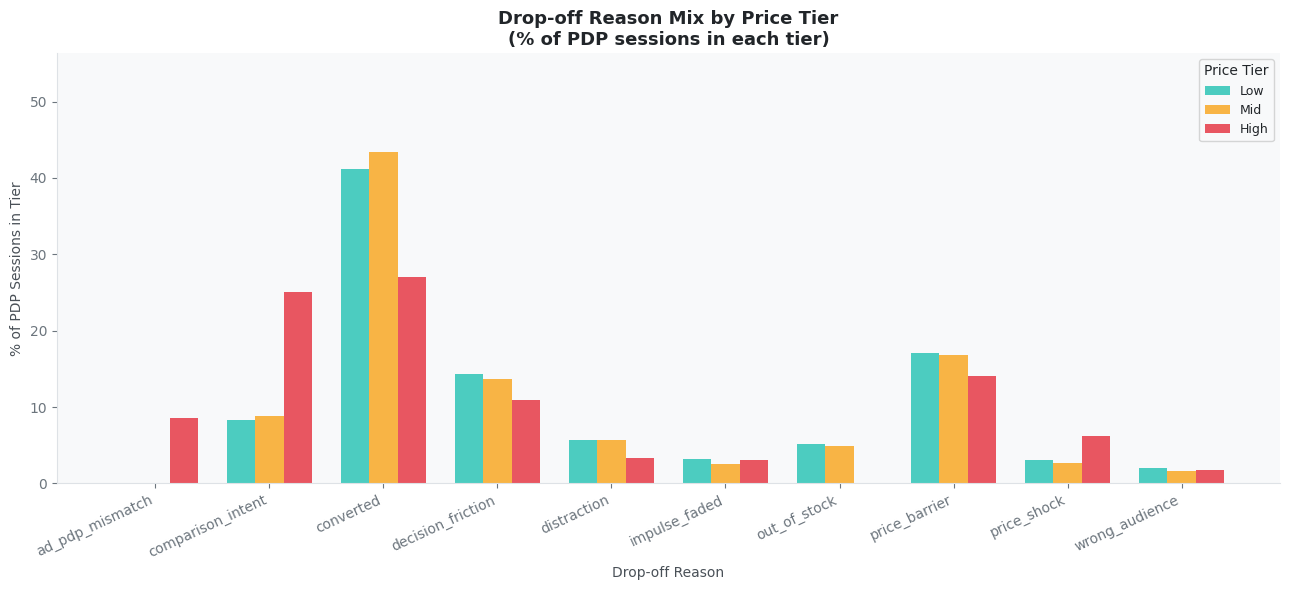


💡 Key Findings:
  High-price decision_friction: 10.9% vs Low-price: 14.3%
  High-price comparison_intent: 25.0% vs Low-price: 8.3%
  Low-price impulse_faded:      3.2% vs High-price: 3.0%

  → High-price drop-off is dominated by FIXABLE reasons
    (decision_friction + comparison_intent)
  → Low-price drop-off has more UNFIXABLE reasons
    (impulse_faded + wrong_audience)


In [8]:
print("=" * 62)
print("DROP-OFF REASON × PRICE TIER")
print("=" * 62)
print("""
The most important cross-tab in the entire analysis.
Shows that high-price products have more decision_friction
and comparison_intent — actionable reasons we CAN fix.
Low-price products have more impulse/wrong_audience —
harder to fix with PDP content.
""")

reason_tier = (
    pdp_sessions.groupby(['price_tier','dropoff_reason'])
    .size()
    .reset_index(name='sessions')
)

# Compute % within each price tier
tier_totals = pdp_sessions.groupby('price_tier').size()
reason_tier['pct_of_tier'] = reason_tier.apply(
    lambda r: r['sessions']/tier_totals[r['price_tier']], axis=1)

# Pivot for display
pivot_reason = reason_tier.pivot(
    index='dropoff_reason',
    columns='price_tier',
    values='pct_of_tier'
)[['low','mid','high']].fillna(0)

print("\nDrop-off reason mix by price tier (% of PDP sessions in that tier):")
display(pivot_reason.round(3))

# Visualization
fig, ax = plt.subplots(figsize=(13, 6))
ax.set_title('Drop-off Reason Mix by Price Tier\n'
             '(% of PDP sessions in each tier)',
             fontsize=13, fontweight='bold')

x      = np.arange(len(pivot_reason.index))
width  = 0.25
colors = ['#2ec4b6','#f9a825','#e63946']

for i, (tier, color) in enumerate(zip(['low','mid','high'], colors)):
    bars = ax.bar(x + i*width, pivot_reason[tier]*100,
                  width, label=tier.capitalize(),
                  color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(pivot_reason.index, rotation=25, ha='right')
ax.set_ylabel('% of PDP Sessions in Tier')
ax.set_xlabel('Drop-off Reason')
ax.legend(title='Price Tier', fontsize=9)
ax.set_ylim(0, pivot_reason.values.max()*130)

plt.tight_layout()
plt.savefig('../data/dropoff_reason_by_tier.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Key insight
high_df = pivot_reason['high']
low_df  = pivot_reason['low']
print(f"\n💡 Key Findings:")
print(f"  High-price decision_friction: {high_df.get('decision_friction',0):.1%} "
      f"vs Low-price: {low_df.get('decision_friction',0):.1%}")
print(f"  High-price comparison_intent: {high_df.get('comparison_intent',0):.1%} "
      f"vs Low-price: {low_df.get('comparison_intent',0):.1%}")
print(f"  Low-price impulse_faded:      {low_df.get('impulse_faded',0):.1%} "
      f"vs High-price: {high_df.get('impulse_faded',0):.1%}")
print(f"\n  → High-price drop-off is dominated by FIXABLE reasons")
print(f"    (decision_friction + comparison_intent)")
print(f"  → Low-price drop-off has more UNFIXABLE reasons")
print(f"    (impulse_faded + wrong_audience)")

SCROLL DEPTH ANALYSIS

Scroll depth tells us HOW MUCH of the page users read.
Combined with drop-off reason it reveals:
  High scroll + no ATC = read everything, still not convinced
  → This is decision friction — most addressable by PDP changes

  Low scroll + no ATC = barely saw the page
  → Price shock, impulse faded — less addressable



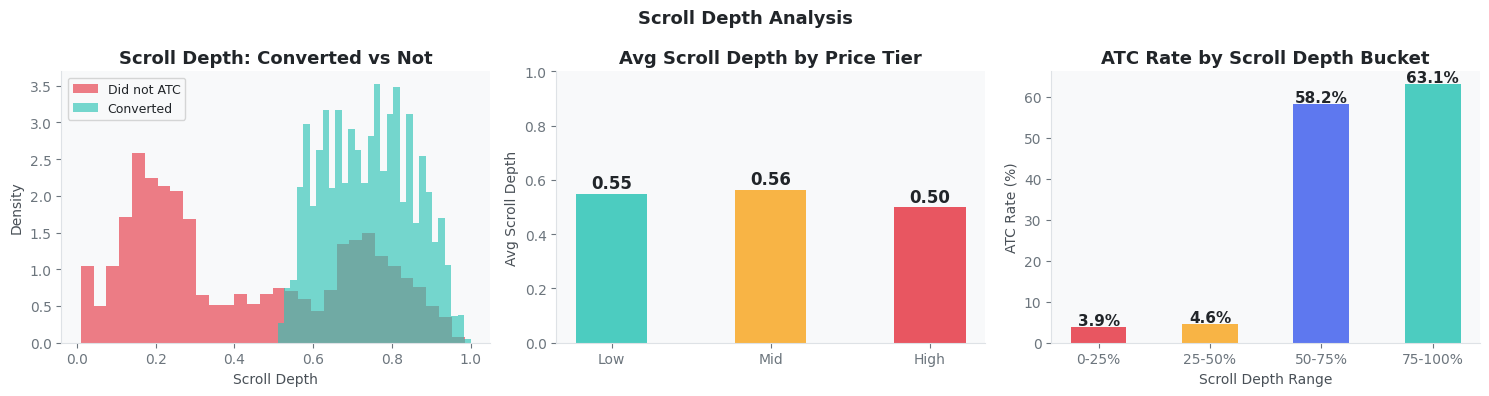


💡 Key Finding:
  Users who scroll 75-100% of the page have 63.1% ATC rate
  Users who scroll 0-25% have 3.9% ATC rate
  → Deep scrollers are 16.3x more likely to convert


In [9]:
print("=" * 55)
print("SCROLL DEPTH ANALYSIS")
print("=" * 55)
print("""
Scroll depth tells us HOW MUCH of the page users read.
Combined with drop-off reason it reveals:
  High scroll + no ATC = read everything, still not convinced
  → This is decision friction — most addressable by PDP changes
  
  Low scroll + no ATC = barely saw the page
  → Price shock, impulse faded — less addressable
""")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Scroll Depth Analysis', fontsize=13, fontweight='bold')

# Left: scroll depth distribution for churned vs converted
ax = axes[0]
converted_scroll = pdp_sessions[
    pdp_sessions['dropoff_reason']=='converted']['avg_scroll_depth'].dropna()
non_converted_scroll = pdp_sessions[
    pdp_sessions['dropoff_reason']!='converted']['avg_scroll_depth'].dropna()

ax.hist(non_converted_scroll, bins=30, alpha=0.65,
        color='#e63946', label='Did not ATC', density=True)
ax.hist(converted_scroll, bins=30, alpha=0.65,
        color='#2ec4b6', label='Converted', density=True)
ax.set_xlabel('Scroll Depth')
ax.set_ylabel('Density')
ax.set_title('Scroll Depth: Converted vs Not')
ax.legend(fontsize=9)

# Middle: avg scroll by price tier
ax2 = axes[1]
scroll_by_tier = (
    pdp_sessions.groupby('price_tier')['avg_scroll_depth']
    .mean().reindex(['low','mid','high'])
)
colors_t = ['#2ec4b6','#f9a825','#e63946']
bars = ax2.bar([t.capitalize() for t in scroll_by_tier.index],
               scroll_by_tier.values,
               color=colors_t, width=0.45, alpha=0.85)
ax2.set_title('Avg Scroll Depth by Price Tier')
ax2.set_ylabel('Avg Scroll Depth')
ax2.set_ylim(0, 1.0)
for bar, v in zip(bars, scroll_by_tier.values):
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.02,
             f'{v:.2f}', ha='center', fontsize=12, fontweight='bold')

# Right: scroll depth buckets → ATC rate
ax3 = axes[2]
pdp_sessions['scroll_bucket'] = pd.cut(
    pdp_sessions['avg_scroll_depth'],
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=['0-25%','25-50%','50-75%','75-100%']
)
scroll_atc = (
    pdp_sessions.groupby('scroll_bucket', observed=True)
    .agg(sessions=('reached_atc','count'),
         atc=('reached_atc','sum'))
    .reset_index()
)
scroll_atc['atc_rate'] = scroll_atc['atc'] / scroll_atc['sessions']

scroll_colors = ['#e63946','#f9a825','#4361ee','#2ec4b6']
bars3 = ax3.bar(scroll_atc['scroll_bucket'].astype(str),
                scroll_atc['atc_rate']*100,
                color=scroll_colors, width=0.5, alpha=0.85)
ax3.set_title('ATC Rate by Scroll Depth Bucket')
ax3.set_xlabel('Scroll Depth Range')
ax3.set_ylabel('ATC Rate (%)')
for bar, v in zip(bars3, scroll_atc['atc_rate']):
    ax3.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.5,
             f'{v:.1%}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/scroll_depth_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n💡 Key Finding:")
print(f"  Users who scroll 75-100% of the page have "
      f"{scroll_atc[scroll_atc['scroll_bucket']=='75-100%']['atc_rate'].values[0]:.1%} ATC rate")
print(f"  Users who scroll 0-25% have "
      f"{scroll_atc[scroll_atc['scroll_bucket']=='0-25%']['atc_rate'].values[0]:.1%} ATC rate")
print(f"  → Deep scrollers are {scroll_atc[scroll_atc['scroll_bucket']=='75-100%']['atc_rate'].values[0] / scroll_atc[scroll_atc['scroll_bucket']=='0-25%']['atc_rate'].values[0]:.1f}x more likely to convert")

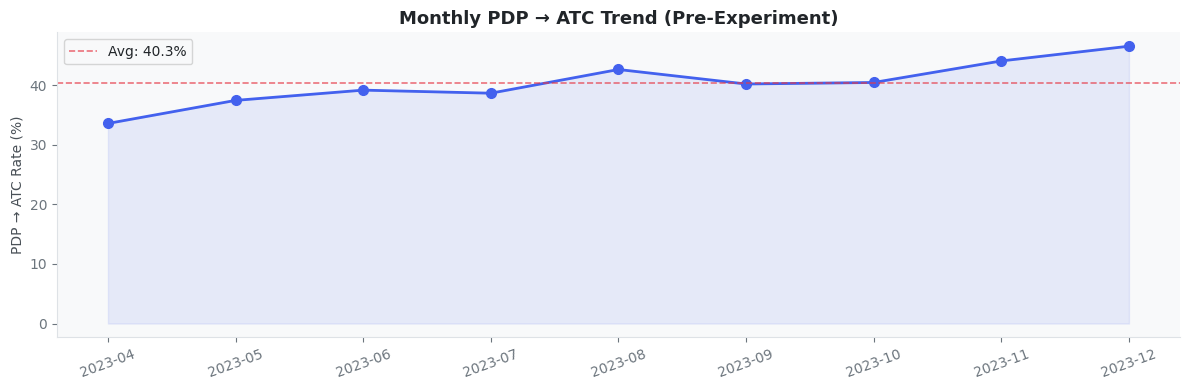

Average PDP→ATC: 40.31%
Min: 33.59% | Max: 46.55%


In [10]:
sessions['month'] = sessions['session_start'].dt.to_period('M')

monthly = (
    sessions[sessions['reached_pdp']==True]
    .groupby('month')
    .agg(
        pdp_users = ('reached_pdp', 'sum'),
        atc_users = ('reached_atc', 'sum'),
    )
    .reset_index()
)
monthly['pdp_to_atc'] = monthly['atc_users'] / monthly['pdp_users']
monthly['month_str']  = monthly['month'].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['month_str'], monthly['pdp_to_atc']*100,
        marker='o', linewidth=2, color='#4361ee', markersize=7)
ax.fill_between(monthly['month_str'],
                monthly['pdp_to_atc']*100,
                alpha=0.10, color='#4361ee')
avg_line = monthly['pdp_to_atc'].mean()*100
ax.axhline(avg_line, color='#e63946', linestyle='--',
           linewidth=1.2, alpha=0.7,
           label=f'Avg: {monthly["pdp_to_atc"].mean():.1%}')
ax.set_ylabel('PDP → ATC Rate (%)')
ax.set_title('Monthly PDP → ATC Trend (Pre-Experiment)')
ax.tick_params(axis='x', labelrotation=20)
ax.legend()
plt.tight_layout()
plt.savefig('../data/monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average PDP→ATC: {monthly['pdp_to_atc'].mean():.2%}")
print(f"Min: {monthly['pdp_to_atc'].min():.2%} | "
      f"Max: {monthly['pdp_to_atc'].max():.2%}")

In [11]:
print("=" * 68)
print("KEY FINDINGS — FUNNEL ANALYSIS v2 (FULL FUNNEL + DROP-OFF REASONS)")
print("=" * 68)

# ── Compute key stats ──────────────────────────────────────────────────
home_to_plp_avg = plp / home
plp_to_pdp_avg  = pdp / plp
pdp_to_atc_avg  = atc / pdp

social_h2p = source_funnel[
    source_funnel['traffic_source'].isin(['facebook','instagram'])
]['home_to_plp'].mean()

direct_h2p = source_funnel[
    source_funnel['traffic_source']=='direct']['home_to_plp'].values[0]

high_tier_row = tier_funnel[tier_funnel['price_tier']=='high'].iloc[0]
low_tier_row  = tier_funnel[tier_funnel['price_tier']=='low'].iloc[0]

fix_pct = reason_summary[reason_summary['dropoff_reason'].isin(
    ['decision_friction','comparison_intent'])]['pct_of_pdp'].sum()
unfix_pct = reason_summary[reason_summary['dropoff_reason'].isin(
    ['impulse_faded','wrong_audience','ad_pdp_mismatch'])]['pct_of_pdp'].sum()

# Decision friction users within high-price specifically
df_high_friction = pdp_sessions[
    (pdp_sessions['price_tier']=='high') &
    (pdp_sessions['dropoff_reason']=='decision_friction')
]
high_df_scroll = df_high_friction['avg_scroll_depth'].mean()
high_df_views  = df_high_friction['pdp_view_count'].mean()

# Scroll depth ATC rates
atc_0_25  = scroll_atc[scroll_atc['scroll_bucket']=='0-25%']['atc_rate'].values[0]
atc_75_100= scroll_atc[scroll_atc['scroll_bucket']=='75-100%']['atc_rate'].values[0]
scroll_lift = atc_75_100 / atc_0_25

# ── Print findings ─────────────────────────────────────────────────────
print(f"""
1. FULL FUNNEL PICTURE
   Home → PLP:        {home_to_plp_avg:.1%}  (social traffic drops off here)
   PLP  → PDP:        {plp_to_pdp_avg:.1%}  (discovery friction)
   PDP  → ATC:        {pdp_to_atc_avg:.1%}  ← PRIMARY OPPORTUNITY
   ATC  → Checkout:   {atc/pdp:.1%}
   Checkout → Buy:    {purchase/checkout:.1%}  (healthy)
   Overall CVR:        {purchase/home:.2%}
   Average Order Value: ${aov:.2f}

2. TRAFFIC SOURCE DROP-OFF LOCATION
   Direct/Email lose most users at PDP→ATC (high intent, reach PDP)
   Social (FB/IG) lose {1-social_h2p:.1%} of users at Home Page alone
   Direct reaches PLP: {direct_h2p:.1%} vs Social: {social_h2p:.1%}
   → Different sources require different interventions:
     Social needs better landing pages + ad-PDP consistency
     Direct/Email needs better PDP value signals

3. HIGH-PRICE PRODUCTS — THREE CONVERGING SIGNALS
   PDP→ATC rate:   {high_tier_row['pdp_to_atc']:.1%} vs {low_tier_row['pdp_to_atc']:.1%} for low-price
   Gap:            {low_tier_row['pdp_to_atc']-high_tier_row['pdp_to_atc']:.1%} lower ATC for high-price products

   Among DECISION FRICTION users specifically (high-price):
   Avg scroll depth:  {high_df_scroll:.2f} (reads deeply — genuinely engaged)
   Avg PDP views:     {high_df_views:.2f} (returns to page multiple times)
   → These users show real intent but still do not convert
   → This is the exact population value messaging targets

   Note: overall high-price avg scroll is pulled down by
   price_shock/price_barrier users who bounce quickly.
   The decision friction problem is concentrated in a specific
   subset of high-price visitors — not all high-price users.

4. DROP-OFF REASON BREAKDOWN
   {fix_pct:.1%} of PDP sessions involve FIXABLE drop-off reasons:
     decision_friction + comparison_intent
     → addressable with value messaging + compare features
   {unfix_pct:.1%} of PDP sessions involve HARDER TO FIX reasons:
     impulse_faded + wrong_audience + ad_pdp_mismatch
     → require upstream fixes (targeting, ad creative, page load)

5. SCROLL DEPTH → ATC RELATIONSHIP
   0-25% scroll:    {atc_0_25:.1%} ATC rate
   75-100% scroll:  {atc_75_100:.1%} ATC rate
   → Deep scrollers convert {scroll_lift:.1f}x better than shallow scrollers
   → Value messaging specifically targets decision_friction users
     who scroll deeply but still do not add to cart
   → This is the highest-ROI PDP intervention target
""")

print("=" * 68)
print("→ Next: 03_segmentation.ipynb")

KEY FINDINGS — FUNNEL ANALYSIS v2 (FULL FUNNEL + DROP-OFF REASONS)

1. FULL FUNNEL PICTURE
   Home → PLP:        57.0%  (social traffic drops off here)
   PLP  → PDP:        47.2%  (discovery friction)
   PDP  → ATC:        40.0%  ← PRIMARY OPPORTUNITY
   ATC  → Checkout:   40.0%
   Checkout → Buy:    83.4%  (healthy)
   Overall CVR:        4.87%
   Average Order Value: $44.06

2. TRAFFIC SOURCE DROP-OFF LOCATION
   Direct/Email lose most users at PDP→ATC (high intent, reach PDP)
   Social (FB/IG) lose 64.8% of users at Home Page alone
   Direct reaches PLP: 79.8% vs Social: 35.2%
   → Different sources require different interventions:
     Social needs better landing pages + ad-PDP consistency
     Direct/Email needs better PDP value signals

3. HIGH-PRICE PRODUCTS — THREE CONVERGING SIGNALS
   PDP→ATC rate:   25.5% vs 41.8% for low-price
   Gap:            16.3% lower ATC for high-price products

   Among DECISION FRICTION users specifically (high-price):
   Avg scroll depth:  0.81 (